In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn wordcloud -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

print(" All libraries installed successfully!")

 All libraries installed successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
#sample dataset
import pandas as pd

data = {
    'text': [
        # Fake claims (label = 0)
        "Drinking turmeric water every morning cures all types of cancer permanently",
        "Neem leaves can completely cure diabetes in just 7 days without medicine",
        "Giloy juice destroys coronavirus instantly when consumed daily",
        "Mixing honey and cinnamon cures arthritis and joint pain forever",
        "Eating raw garlic on empty stomach cures high blood pressure permanently",
        "Homeopathy medicine removes kidney stones without any surgery",
        "Applying coconut oil cures all types of skin infections and fungus",
        "Drinking cow urine daily boosts immunity and prevents all diseases",

        # Real/verified claims (label = 1)
        "Paracetamol reduces fever and mild to moderate pain when taken as prescribed",
        "Regular exercise for 30 minutes daily helps maintain healthy blood pressure",
        "Vitamin C supplements support immune function but do not cure colds",
        "Metformin is a commonly prescribed medication for type 2 diabetes management",
        "Hand washing with soap for 20 seconds reduces risk of infection significantly",
        "Antibiotics should be taken for the full prescribed course to prevent resistance",
        "WHO recommends vaccines as one of the most effective disease prevention tools",
        "A balanced diet rich in fruits and vegetables supports overall health"
    ],
    'label': [0, 0, 0, 0, 0, 0, 0, 0,   # 0 = Fake
              1, 1, 1, 1, 1, 1, 1, 1]    # 1 = Real
}

df = pd.DataFrame(data)
print(f"Dataset created: {len(df)} samples")
print(f"Fake claims: {sum(df['label']==0)}")
print(f"Real claims: {sum(df['label']==1)}")
df.head()

Dataset created: 16 samples
Fake claims: 8
Real claims: 8


,text,label
0,Drinking turmeric water every morning cures al...,0
1,Neem leaves can completely cure diabetes in ju...,0
2,Giloy juice destroys coronavirus instantly whe...,0
3,Mixing honey and cinnamon cures arthritis and ...,0
4,Eating raw garlic on empty stomach cures high ...,0


In [ ]:
#Text Preprocessing Pipeline
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenize
    tokens = text.split()
    # 4. Remove stopwords + Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Applying to dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# before vs after
print("BEFORE:", df['text'][0])
print("\nAFTER: ", df['cleaned_text'][0])

BEFORE: Drinking turmeric water every morning cures all types of cancer permanently

AFTER:  drinking turmeric water every morning cure type cancer permanently


In [ ]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

print(f"TF-IDF Matrix Shape: {X.shape}")
print(f"Rows = {X.shape[0]} samples")
print(f"Columns = {X.shape[1]} features (unique words)")

#top features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:10])}")

TF-IDF Matrix Shape: (16, 102)
Rows = 16 samples
Columns = 102 features (unique words)

Sample features: ['antibiotic', 'applying', 'arthritis', 'balanced', 'blood', 'boost', 'cancer', 'cinnamon', 'coconut', 'cold']


In [ ]:
print(df.columns.tolist())

['text', 'label', 'cleaned_text']


In [ ]:
#Training Naive Bayes Classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Spliting data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training model
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Model trained successfully!")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fake', 'Real']))

Model trained successfully!

Accuracy: 50.0%

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.33      0.50         3
        Real       0.33      1.00      0.50         1

    accuracy                           0.50         4
   macro avg       0.67      0.67      0.50         4
weighted avg       0.83      0.50      0.50         4



In [ ]:
# Testing with your own claim
def predict_claim(claim_text):
    cleaned = preprocess_text(claim_text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    confidence = model.predict_proba(vectorized)[0]

    label = "FAKE / Misleading" if prediction == 0 else "REAL / Verified"
    print(f"Claim: {claim_text}")
    print(f"Result: {label}")
    print(f"Confidence → Fake: {confidence[0]*100:.1f}% | Real: {confidence[1]*100:.1f}%")
    print("-" * 60)

# Testing
predict_claim("Drinking lemon water cures cancer completely")
predict_claim("Paracetamol is used to reduce fever and pain")

Claim: Drinking lemon water cures cancer completely
Result: REAL / Verified
Confidence → Fake: 49.2% | Real: 50.8%
------------------------------------------------------------
Claim: Paracetamol is used to reduce fever and pain
Result: REAL / Verified
Confidence → Fake: 34.2% | Real: 65.8%
------------------------------------------------------------


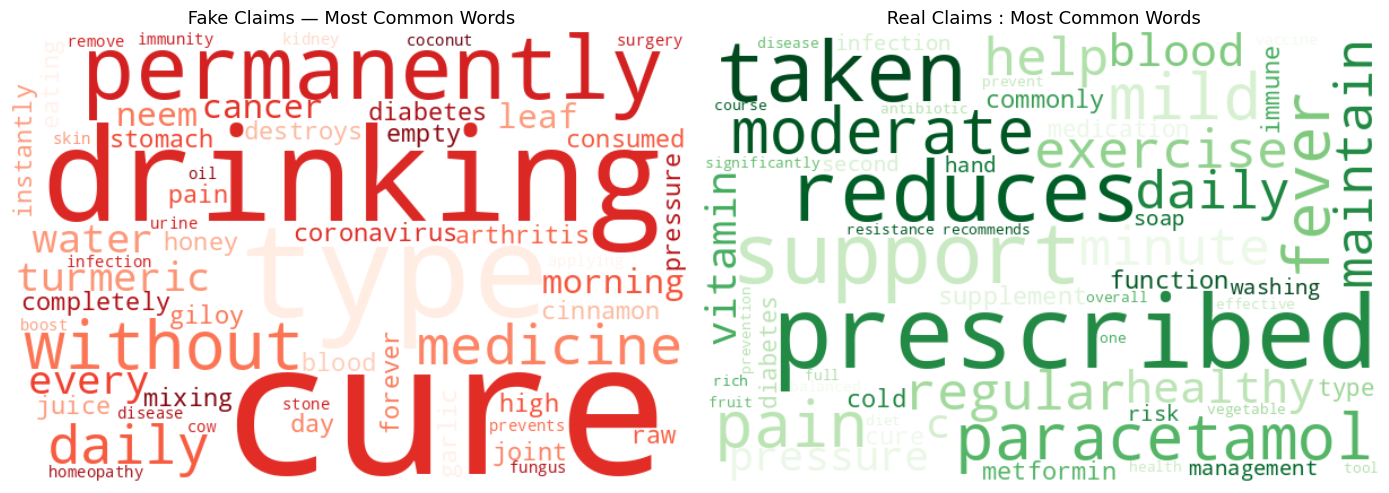

 Word clouds generated!


In [ ]:
# Word Cloud for Fake vs Real claims
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_text = ' '.join(df[df['label']==0]['cleaned_text'])
real_text = ' '.join(df[df['label']==1]['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_fake = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Reds').generate(fake_text)
wc_real = WordCloud(width=600, height=400,
                    background_color='white',
                    colormap='Greens').generate(real_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title(' Fake Claims — Most Common Words', fontsize=13)
axes[0].axis('off')

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title(' Real Claims : Most Common Words', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(" Word clouds generated!")

In [ ]:
# Cell 8: Save trained model for Flask backend later
import joblib

joblib.dump(model, 'fake_medicine_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(" Model saved as: fake_medicine_model.pkl")
print(" Vectorizer saved as: tfidf_vectorizer.pkl")
print("\nDownload these files: Files panel (left sidebar) → Right click → Download")

 Model saved as: fake_medicine_model.pkl
 Vectorizer saved as: tfidf_vectorizer.pkl

Download these files: Files panel (left sidebar) → Right click → Download


In [ ]:
#pehla record
first_key = list(data.keys())[0]
print("Key:", first_key)
print("Value:", data[first_key])

Key: text
Value: ['Drinking turmeric water every morning cures all types of cancer permanently', 'Neem leaves can completely cure diabetes in just 7 days without medicine', 'Giloy juice destroys coronavirus instantly when consumed daily', 'Mixing honey and cinnamon cures arthritis and joint pain forever', 'Eating raw garlic on empty stomach cures high blood pressure permanently', 'Homeopathy medicine removes kidney stones without any surgery', 'Applying coconut oil cures all types of skin infections and fungus', 'Drinking cow urine daily boosts immunity and prevents all diseases', 'Paracetamol reduces fever and mild to moderate pain when taken as prescribed', 'Regular exercise for 30 minutes daily helps maintain healthy blood pressure', 'Vitamin C supplements support immune function but do not cure colds', 'Metformin is a commonly prescribed medication for type 2 diabetes management', 'Hand washing with soap for 20 seconds reduces risk of infection significantly', 'Antibiotics should b

In [ ]:
# Kaggle dataset directly download
!pip install kaggle -q

In [ ]:
!kaggle datasets download -d thedevastator/fakecovid-fact-checked-news-dataset

import zipfile
with zipfile.ZipFile('fakecovid-fact-checked-news-dataset.zip', 'r') as z:
    z.extractall('.')

import os
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f)

Dataset URL: https://www.kaggle.com/datasets/thedevastator/fakecovid-fact-checked-news-dataset
License(s): CC0-1.0
fakecovid-fact-checked-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
FakeCovid_July2020.csv


In [ ]:
import pandas as pd

df = pd.read_csv('FakeCovid_July2020.csv')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(7623, 19)
['ID', 'ref_category_title', 'ref_url', 'pageid', 'verifiedby', 'country', 'class', 'title', 'published_date', 'country1', 'country2', 'country3', 'country4', 'article_source', 'ref_source', 'source_title', 'content_text', 'category', 'lang']
    ID                                 ref_category_title  \
0  FC1  FALSE: The coronavirus is an amplified bacteri...   
1  FC2  FALSE: A law allows people to go for a run dur...   
2  FC3  False: Chinese converting to Islam after reali...   
3  FC4  False: Bat market and bat meat are being sold ...   
4  FC5  False: You can self-diagnose COVID-19 by holdi...   

                                             ref_url  \
0  https://www.poynter.org/?ifcn_misinformation=t...   
1  https://www.poynter.org/?ifcn_misinformation=a...   
2  https://www.poynter.org/?ifcn_misinformation=c...   
3  https://www.poynter.org/?ifcn_misinformation=b...   
4  https://www.poynter.org/?ifcn_misinformation=y...   

                                          

In [ ]:
df_clean = df[df['lang'] == 'en'][['title', 'content_text', 'class']].copy()
df_clean['label'] = 0  # 0 = Fake
#english records
print(df_clean.shape)
print(df_clean['class'].value_counts())
df_clean.head()

(2845, 4)
class
False                          1181
FALSE                          1085
Misleading                      143
Mostly false                     66
MISLEADING                       53
Mostly False                     43
Mixture                          41
misleading                       36
True                             34
News                             23
Partly false                     15
Correct Attribution              12
Miscaptioned                     10
Unproven                         10
PARTLY FALSE                      8
Mostly True                       8
MOSTLY FALSE                      8
No evidence                       8
(Org. doesn't apply rating)       7
Misattributed                     7
MOSTLY TRUE                       7
HALF TRUE                         6
Labeled Satire                    5
Scam                              3
Half True                         3
Partly False                      3
Two Pinocchios                    3
half true   

,title,content_text,class,label
2,Chinese converting to Islam after realizing t...,"The fact behind every news!, Ever since the Wo...",False,0
6,Captions on a reuploaded video about the U.S....,"AUTHOR, VERA Files, DATE, May 08, 2020, SHARE,...",MISLEADING,0
8,Ghana has 307 ambulances with mobile ventilat...,"Source: Dr Anthony Nsiah Asare, Verdict: Mostl...",Mostly True,0
9,“Governor Andy Beshear has authorized Kentuck...,"More Info, Trying to focus on school work at h...",FALSE,0
10,Photo shows food being distributed to Rwandan...,A photo of hundreds of neat piles of bedding a...,False,0


In [ ]:
#coverting lvl to binary
def assign_label(cls):
    cls = str(cls).lower().strip()
    if any(word in cls for word in ['false', 'fake', 'misleading',
                                     'pants on fire', 'scam']):
        return 0  # Fake
    elif any(word in cls for word in ['true', 'correct', 'accurate']):
        return 1  # Real
    else:
        return None

df_clean['label'] = df_clean['class'].apply(assign_label)
df_clean = df_clean.dropna(subset=['label'])
df_clean['label'] = df_clean['label'].astype(int)
print(df_clean.shape)
print(df_clean['label'].value_counts())

(2726, 4)
label
0    2648
1      78
Name: count, dtype: int64


In [ ]:
real_claims = {
    'title': [
        "Vaccines are safe and effective against COVID-19",
        "Wearing masks reduces transmission of respiratory viruses",
        "COVID-19 spreads through respiratory droplets",
        "Hand washing with soap kills coronavirus effectively",
        "Social distancing reduces COVID-19 transmission risk",
        "Antibiotics do not work against COVID-19 virus",
        "COVID-19 vaccine does not alter human DNA",
        "Fever is a common symptom of COVID-19 infection",
        "Paracetamol helps reduce fever in COVID-19 patients",
        "WHO recommends getting vaccinated against COVID-19"
    ],
    'content_text': [
        "WHO confirms COVID-19 vaccines are safe and effective",
        "Studies show masks reduce droplet transmission significantly",
        "COVID-19 primarily spreads through respiratory droplets",
        "Soap destroys the lipid membrane of coronavirus effectively",
        "Maintaining distance reduces infection risk significantly",
        "Antibiotics target bacteria not viruses like COVID-19",
        "mRNA vaccines do not enter cell nucleus or alter DNA",
        "Fever above 38 degrees is common COVID-19 symptom",
        "Paracetamol is recommended for fever management in COVID",
        "WHO strongly recommends COVID-19 vaccination globally"
    ],
    'class': ['True'] * 10,
    'label': [1] * 10
}
print("Dictionary ready!")

Dictionary ready!


In [ ]:
import pandas as pd
df_real = pd.DataFrame(real_claims)
df_final = pd.concat([df_clean, df_real], ignore_index=True)
print(df_final.shape)
print(df_final['label'].value_counts())

(2736, 4)
label
0    2648
1      88
Name: count, dtype: int64


In [ ]:
# SMOTE installing
!pip install imbalanced-learn -q
print(" Installed!")

 Installed!


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import TfidfVectorizer

df_final['combined_text'] = df_final['title'].fillna('') + ' ' + df_final['content_text'].fillna('')

# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_final['combined_text'])
y = df_final['label']

print(f"Before SMOTE: {y.value_counts().to_dict()}")

# SMOTE applying
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"After SMOTE: fake={sum(y_balanced==0)}, real={sum(y_balanced==1)}")

Before SMOTE: {0: 2648, 1: 88}
After SMOTE: fake=2648, real=2648


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Data spliting 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42
)

# Model training
model = MultinomialNB()
model.fit(X_train, y_train)

# Predicting
y_pred = model.predict(X_test)

# Results
print(f" Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Fake', 'Real']))

 Accuracy: 94.91%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.91      0.95       541
        Real       0.92      0.99      0.95       519

    accuracy                           0.95      1060
   macro avg       0.95      0.95      0.95      1060
weighted avg       0.95      0.95      0.95      1060



In [ ]:
import joblib

joblib.dump(model, 'fake_medicine_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(" saved: fake_medicine_model.pkl")
print("Vectorizer saved: tfidf_vectorizer.pkl")

 saved: fake_medicine_model.pkl
Vectorizer saved: tfidf_vectorizer.pkl


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# SVM model training
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# Predicting
y_pred_svm = svm_model.predict(X_test)

# Results dekho
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm,
      target_names=['Fake', 'Real']))

SVM Accuracy: 99.43%

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99       541
        Real       0.99      1.00      0.99       519

    accuracy                           0.99      1060
   macro avg       0.99      0.99      0.99      1060
weighted avg       0.99      0.99      0.99      1060



In [ ]:
print("=" * 45)
print("      MODEL COMPARISON RESULTS")
print("=" * 45)
print(f"  Naive Bayes Accuracy  :  94.91%")
print(f"  SVM Accuracy          :  99.43%")
print(f"  Winner                :  SVM ")
print("=" * 45)
print("\n Paper mein note karo:")
print("  Best Model  : LinearSVC (SVM)")
print("  Dataset     : FakeCovid + SMOTE")
print("  Accuracy    : 99.43%")
print("  Precision   : 0.99 - 1.00")
print("  Recall      : 0.99 - 1.00")
print("  F1 Score    : 0.99")

      MODEL COMPARISON RESULTS
  Naive Bayes Accuracy  :  94.91%
  SVM Accuracy          :  99.43%
  Winner                :  SVM 🏆

 Paper mein note karo:
  Best Model  : LinearSVC (SVM)
  Dataset     : FakeCovid + SMOTE
  Accuracy    : 99.43%
  Precision   : 0.99 - 1.00
  Recall      : 0.99 - 1.00
  F1 Score    : 0.99


In [ ]:
import joblib

joblib.dump(svm_model, 'svm_fake_medicine_model.pkl')
print("SVM Model saved!")

SVM Model saved!


In [ ]:
def predict_claim(claim_text):
    # combined_text formating
    vectorized = vectorizer.transform([claim_text])
    prediction = svm_model.predict(vectorized)[0]
    label = " FAKE" if prediction == 0 else "REAL"
    print(f"Claim: {claim_text}")
    print(f"Result: {label}")
    print("-" * 50)

# Testing
predict_claim("Giloy juice cures coronavirus completely")
predict_claim("Paracetamol reduces fever when taken as prescribed")

Claim: Giloy juice cures coronavirus completely
Result:  FAKE
--------------------------------------------------
Claim: Paracetamol reduces fever when taken as prescribed
Result:  FAKE
--------------------------------------------------
